,cement,slag,fly_ash,water,plasticizer,gravel,sand,age_days,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,80.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.9
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.3
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.1
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.3


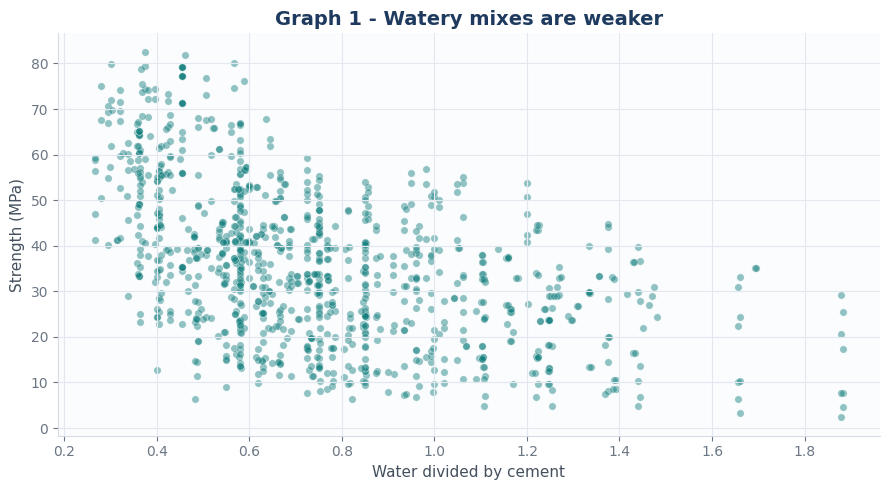

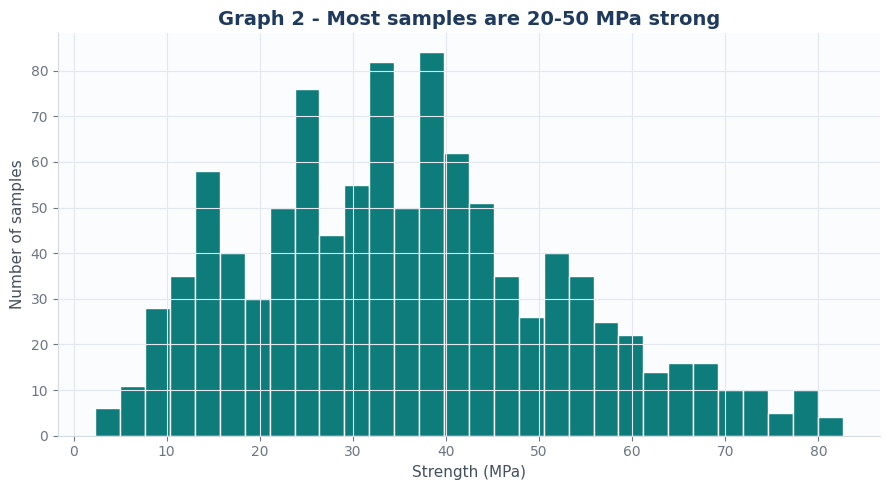

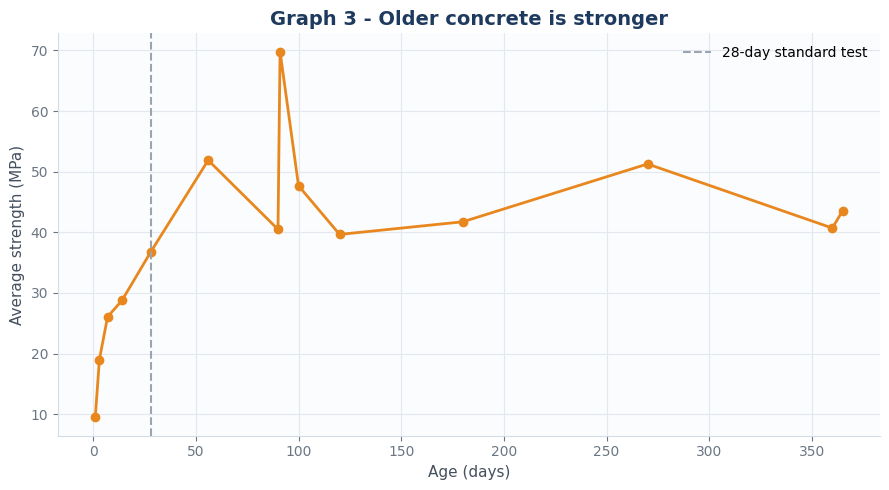

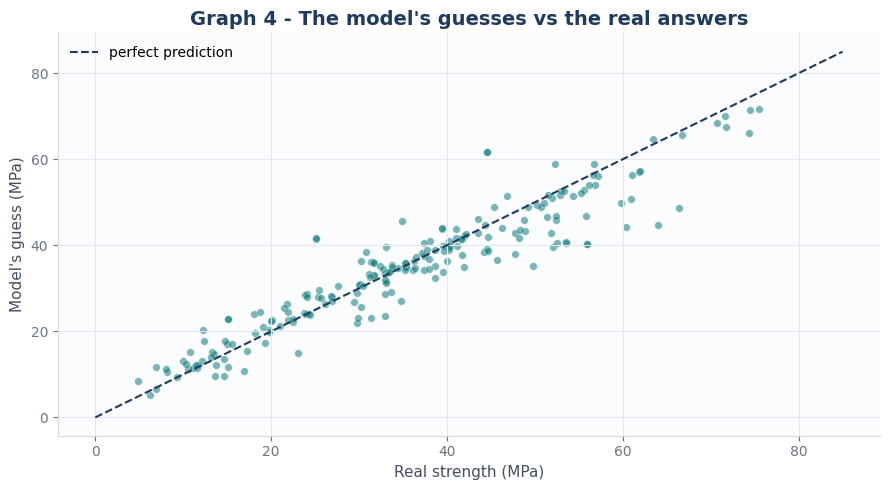

In [1]:
# =====================================================================
#  CAN A COMPUTER PREDICT HOW STRONG CONCRETE WILL BE?
#  Name: YOUR NAME HERE
#  Styled edition - paste this whole thing into ONE Colab cell and run.
# =====================================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from IPython.display import display, HTML

# ---------- THE LOOK: colors + chart theme (the "CSS" of the project) ----------
NAVY   = "#1f3a5f"   # headers
TEAL   = "#0e7c7b"   # main accent
ORANGE = "#e8871e"   # highlight
LIGHT  = "#f5f7fa"   # card background
FONT   = "font-family:'Segoe UI',Helvetica,Arial,sans-serif;"

rcParams.update({
    "figure.figsize": (9, 5),   "figure.facecolor": "white",
    "axes.facecolor": "#fbfcfe","axes.edgecolor": "#d5dbe3",
    "axes.titlesize": 14,       "axes.titleweight": "bold",
    "axes.titlecolor": NAVY,    "axes.labelcolor": "#44505e",
    "axes.labelsize": 11,       "axes.grid": True,
    "grid.color": "#e3e8ee",    "grid.linewidth": 0.8,
    "xtick.color": "#6b7683",   "ytick.color": "#6b7683",
    "axes.spines.top": False,   "axes.spines.right": False,
})

def banner(title, subtitle):
    """Big gradient header."""
    display(HTML(f"""
    <div style="{FONT} background:linear-gradient(120deg,{NAVY},{TEAL});
         color:white; border-radius:14px; padding:26px 30px; margin:14px 0;">
      <div style="font-size:26px; font-weight:800; letter-spacing:.3px;">{title}</div>
      <div style="font-size:15px; opacity:.92; margin-top:6px;">{subtitle}</div>
    </div>"""))

def step(number, title, text):
    """Section header card."""
    display(HTML(f"""
    <div style="{FONT} background:{LIGHT}; border-left:6px solid {TEAL};
         border-radius:10px; padding:14px 18px; margin:18px 0 8px 0;">
      <span style="background:{TEAL}; color:white; border-radius:50%;
           padding:4px 11px; font-weight:700; margin-right:10px;">{number}</span>
      <span style="font-size:18px; font-weight:700; color:{NAVY};">{title}</span>
      <div style="font-size:14px; color:#4a5568; margin-top:8px; line-height:1.55;">{text}</div>
    </div>"""))

def note(text, color=ORANGE, icon="&#128161;"):
    """Small highlight card for findings."""
    display(HTML(f"""
    <div style="{FONT} border:1.5px solid {color}; background:{color}12;
         border-radius:10px; padding:12px 16px; margin:10px 0;
         font-size:14px; color:#333; line-height:1.55;">{icon} {text}</div>"""))

def metrics(items):
    """Row of big-number tiles.  items = [(value, label), ...]"""
    tiles = "".join(f"""
      <div style="flex:1; background:white; border:1px solid #e3e8ee;
           border-top:4px solid {TEAL}; border-radius:12px; text-align:center;
           padding:16px 8px; margin:0 6px; box-shadow:0 1px 4px rgba(0,0,0,.06);">
        <div style="font-size:30px; font-weight:800; color:{NAVY};">{v}</div>
        <div style="font-size:12.5px; color:#6b7683; margin-top:4px;">{l}</div>
      </div>""" for v, l in items)
    display(HTML(f'<div style="{FONT} display:flex; margin:12px 0;">{tiles}</div>'))


# ============================ THE PROJECT ============================

banner("Can a Computer Predict How Strong Concrete Will Be?",
       "Testing concrete takes 28 days. This project teaches a computer to predict "
       "strength from the recipe alone &mdash; using 1,030 real lab tests. "
       "Data: UCI Machine Learning Repository (free &amp; public).")

# ---------- STEP 1: GET THE DATA ----------
step(1, "Get the data",
     "Each row is one real concrete sample: its recipe (kg of each ingredient), "
     "its age in days, and the strength measured when it was crushed in a lab.")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
data = pd.read_excel(url)
data.columns = ["cement", "slag", "fly_ash", "water", "plasticizer",
                "gravel", "sand", "age_days", "strength"]

metrics([(f"{len(data):,}", "real lab samples"),
         ("8", "recipe ingredients + age"),
         (f"{data.isna().sum().sum()}", "missing values"),
         (f"{data.strength.min():.0f}-{data.strength.max():.0f}", "strength range (MPa)")])

display(data.head().style.format(precision=1)
        .set_caption("First 5 samples")
        .background_gradient(subset=["strength"], cmap="BuGn"))

# ---------- STEP 2: LOOK FOR PATTERNS ----------
step(2, "Look for patterns",
     "Three graphs, three stories: watery mixes are weaker, most samples land "
     "between 20-50 MPa, and concrete keeps gaining strength as it cures.")

# Graph 1 - more water per unit of cement = weaker concrete
data["water_per_cement"] = data["water"] / data["cement"]
plt.scatter(data["water_per_cement"], data["strength"],
            alpha=0.45, s=28, color=TEAL, edgecolors="white", linewidths=.4)
plt.xlabel("Water divided by cement")
plt.ylabel("Strength (MPa)")
plt.title("Graph 1 - Watery mixes are weaker")
plt.tight_layout(); plt.show()

# Graph 2 - what strengths are common?
plt.hist(data["strength"], bins=30, color=TEAL, edgecolor="white")
plt.xlabel("Strength (MPa)")
plt.ylabel("Number of samples")
plt.title("Graph 2 - Most samples are 20-50 MPa strong")
plt.tight_layout(); plt.show()

# Graph 3 - concrete gets stronger as it ages
by_age = data.groupby("age_days")["strength"].mean()
plt.plot(by_age.index, by_age.values, marker="o", color=ORANGE, linewidth=2)
plt.axvline(28, color="#9aa5b1", linestyle="--", label="28-day standard test")
plt.xlabel("Age (days)")
plt.ylabel("Average strength (MPa)")
plt.title("Graph 3 - Older concrete is stronger")
plt.legend(frameon=False)
plt.tight_layout(); plt.show()

note("<b>My finding:</b> strength drops as the water-to-cement ratio rises &mdash; "
     "extra water leaves tiny holes in the hardened concrete. Engineers call this "
     "<b>Abrams' law</b>, and my data confirms it.")

# ---------- STEP 3: TEACH THE COMPUTER ----------
step(3, "Teach the computer",
     "The model sees 80% of the samples (recipe &rarr; strength) and learns the "
     "relationship. The other 20% stay hidden for an honest test.")

recipe   = data[["cement", "slag", "fly_ash", "water",
                 "plasticizer", "gravel", "sand", "age_days"]]
strength = data["strength"]

recipe_train, recipe_test, strength_train, strength_test = train_test_split(
    recipe, strength, test_size=0.20, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(recipe_train, strength_train)          # <- the learning happens here

metrics([(f"{len(recipe_train)}", "samples used for learning"),
         (f"{len(recipe_test)}", "samples kept hidden for the test")])

# ---------- STEP 4: TEST THE COMPUTER ----------
step(4, "Test the computer",
     "The model guesses the strength of the 206 hidden recipes. We compare its "
     "guesses to the real crushed-in-a-lab answers.")

guesses = model.predict(recipe_test)
score   = r2_score(strength_test, guesses)             # 1.0 = perfect
error   = mean_absolute_error(strength_test, guesses)  # average miss

metrics([(f"{score:.2f}", "score (R&sup2;) - 1.0 would be perfect"),
         (f"{score:.0%}", "of strength differences explained"),
         (f"&plusmn;{error:.1f} MPa", "average miss (range is 2-82)")])

# Graph 4 - guesses vs reality (dots on the line = perfect)
plt.scatter(strength_test, guesses, alpha=0.55, s=30,
            color=TEAL, edgecolors="white", linewidths=.4)
plt.plot([0, 85], [0, 85], "--", color=NAVY, label="perfect prediction")
plt.xlabel("Real strength (MPa)")
plt.ylabel("Model's guess (MPa)")
plt.title("Graph 4 - The model's guesses vs the real answers")
plt.legend(frameon=False)
plt.tight_layout(); plt.show()

# ---------- STEP 5: THE BOTTOM LINE ----------
step(5, "The bottom line", "")
note(f"<b>Result:</b> the model predicts strength with a score of {score:.2f} "
     f"(&asymp;{score:.0%}) and is only off by about {error:.1f} MPa on average. "
     "It figured out on its own that <b>age, cement and water</b> matter most &mdash; "
     "exactly what engineering theory says.", color=TEAL, icon="&#9989;")
note("<b>Recommendation:</b> use the model to <b>pre-screen</b> new recipes and only "
     "lab-test the most promising ones &mdash; saving ~28 days per rejected recipe. "
     "<b>Next step:</b> build a Raspberry Pi rig to break 3D-printed beams and "
     "collect my own data.", color=ORANGE, icon="&#128640;")
display(HTML(f"""
  <div style="{FONT} text-align:center; color:#8a94a0; font-size:12px; margin:16px 0;">
    Data: UCI Machine Learning Repository &middot; Concrete Compressive Strength (I-Cheng Yeh, 1998)
    &middot; AI note: an AI assistant helped structure this code; I ran, checked, and understand every step.
  </div>"""))


In [2]:
# =====================================================================
#  ABOUT PAGE  -  explains the program + full credit for the dataset
#
#  Paste this into a cell BELOW the main project cell and run it
#  (the main cell must run first - it creates `data`, `model`,
#  `recipe`, `score`, `error` and the styling helpers).
# =====================================================================

from IPython.display import display, HTML

# ---------------- HERO ----------------
display(HTML(f"""
  <div style="{FONT} background:linear-gradient(120deg,{NAVY},{TEAL}); color:white;
       border-radius:14px; padding:24px 30px; margin:14px 0;">
    <div style="font-size:24px; font-weight:800;">&#8505;&#65039; About This Project</div>
    <div style="font-size:14.5px; opacity:.93; margin-top:6px; line-height:1.6;">
      What this program does, how it works under the hood, and full credit for the
      real laboratory data that makes it possible.</div>
  </div>"""))

# ---------------- HOW THE PROGRAM WORKS ----------------
step("&#9881;&#65039;", "How the program works - the 5-stage pipeline", "")
stages = [
    ("1. COLLECT", "Downloads 1,030 real concrete lab tests straight from the UCI research archive. No fake data anywhere in this project."),
    ("2. EXPLORE", "Draws graphs and computes statistics to find patterns - like the water/cement ratio dragging strength down (Abrams' law)."),
    ("3. LEARN", "A Random Forest (200 decision trees) studies 824 of the samples: recipe in, measured strength out. Each tree learns rules like 'IF water is high AND cement is low THEN weak', and the forest averages all 200 opinions."),
    ("4. VERIFY", "The remaining 206 samples are kept hidden during learning, then used as a final exam. The model is graded ONLY on recipes it has never seen - that is what makes the score honest."),
    ("5. APPLY", "The trained model powers two tools: the Calculator (recipe &rarr; predicted strength) and the Mix Designer (target strength &rarr; optimal recipe, testing 20,000 candidates)."),
]
cards = "".join(f"""
  <div style="flex:1; min-width:150px; background:white; border:1px solid #e3e8ee;
       border-top:4px solid {TEAL}; border-radius:12px; padding:14px; margin:5px;">
    <div style="font-weight:800; color:{NAVY}; font-size:13px; letter-spacing:.5px;">{t}</div>
    <div style="font-size:12.5px; color:#4a5568; margin-top:7px; line-height:1.5;">{d}</div>
  </div>""" for t, d in stages)
display(HTML(f'<div style="{FONT} display:flex; flex-wrap:wrap;">{cards}</div>'))

metrics([(f"{len(recipe_train)}", "samples used for learning"),
         (f"{len(recipe_test)}", "samples used for the hidden exam"),
         (f"{score:.2f}", "final score (R&sup2;) on unseen data"),
         (f"&plusmn;{error:.1f} MPa", "average prediction miss")])

# ---------------- THE DATASET CARD ----------------
step("&#128218;", "The dataset - who made it and where it comes from",
     "Real research data, collected in materials laboratories and shared publicly "
     "so anyone in the world can verify or build on the work.")

display(HTML(f"""
  <div style="{FONT} background:white; border:1px solid #e3e8ee; border-radius:12px;
       padding:18px 24px; margin:10px 0; line-height:1.7; font-size:14px; color:#333;">
    <table style="border-collapse:collapse; width:100%; font-size:13.5px;">
      <tr><td style="padding:6px 12px; font-weight:700; color:{NAVY}; width:190px;">Dataset name</td>
          <td style="padding:6px 12px;">Concrete Compressive Strength</td></tr>
      <tr style="background:{LIGHT};"><td style="padding:6px 12px; font-weight:700; color:{NAVY};">Created by</td>
          <td style="padding:6px 12px;"><b>Prof. I-Cheng Yeh</b>, Chung-Hua University, Taiwan</td></tr>
      <tr><td style="padding:6px 12px; font-weight:700; color:{NAVY};">Original research</td>
          <td style="padding:6px 12px;">Yeh, I-C. (1998). "Modeling of strength of high-performance
          concrete using artificial neural networks." <i>Cement and Concrete Research</i>,
          28(12), 1797&ndash;1808. &mdash; one of the FIRST papers ever to use machine
          learning on concrete, 27 years ago.</td></tr>
      <tr style="background:{LIGHT};"><td style="padding:6px 12px; font-weight:700; color:{NAVY};">Published at</td>
          <td style="padding:6px 12px;">UCI Machine Learning Repository (University of California,
          Irvine) &mdash; the world's most-used public archive of research datasets, donated 2007.</td></tr>
      <tr><td style="padding:6px 12px; font-weight:700; color:{NAVY};">Link</td>
          <td style="padding:6px 12px;">archive.ics.uci.edu/dataset/165/concrete+compressive+strength</td></tr>
      <tr style="background:{LIGHT};"><td style="padding:6px 12px; font-weight:700; color:{NAVY};">What one row is</td>
          <td style="padding:6px 12px;">One real batch of concrete: mixed in a lab, cured for a recorded
          number of days, then crushed in a hydraulic press while its breaking strength was measured.</td></tr>
      <tr><td style="padding:6px 12px; font-weight:700; color:{NAVY};">Size &amp; quality</td>
          <td style="padding:6px 12px;">{len(data):,} samples &middot; 9 columns &middot;
          <b>zero missing values</b> (rare for real lab data)</td></tr>
      <tr style="background:{LIGHT};"><td style="padding:6px 12px; font-weight:700; color:{NAVY};">License</td>
          <td style="padding:6px 12px;">Free for research and education (Creative Commons CC BY 4.0)</td></tr>
    </table>
  </div>"""))

note("<b>Why this source is trustworthy:</b> the data comes from a peer-reviewed journal "
     "paper, is hosted by a major university archive, has a named author, and has been "
     "used in hundreds of published studies since 1998. I can cite exactly where every "
     "number in my project comes from.", color=TEAL, icon="&#128737;&#65039;")

# ---------------- WHAT EVERY COLUMN MEANS ----------------
step("&#128209;", "What every column means",
     "Generated live from the loaded data - the ranges below are computed, not typed in.")

DESCRIPTIONS = {
    "cement":      ("The glue. Powder that reacts with water and hardens. Most expensive ingredient, biggest CO&#8322; footprint.", "kg per m&sup3;"),
    "slag":        ("Blast-furnace slag - a steel-industry byproduct that can replace part of the cement (greener).", "kg per m&sup3;"),
    "fly_ash":     ("Ash captured from coal power plants - another cement substitute that would otherwise be waste.", "kg per m&sup3;"),
    "water":       ("Triggers the hardening reaction. Too much leaves pores that weaken the concrete.", "kg per m&sup3;"),
    "plasticizer": ("Superplasticizer - a chemical that keeps the mix workable with LESS water.", "kg per m&sup3;"),
    "gravel":      ("Coarse aggregate - the stones that give the concrete its bulk.", "kg per m&sup3;"),
    "sand":        ("Fine aggregate - fills the gaps between the stones.", "kg per m&sup3;"),
    "age_days":    ("How long the sample cured before being crushed. Concrete keeps strengthening for months.", "days"),
    "strength":    ("THE ANSWER - the compressive strength measured when the sample was crushed. This is what the model predicts.", "MPa (megapascals)"),
}
rows_html = ""
for i, (col, (desc, unit)) in enumerate(DESCRIPTIONS.items()):
    vals = data[col]
    band = f"background:{LIGHT};" if i % 2 else ""
    target_tag = (f' <span style="background:{ORANGE}; color:white; border-radius:20px;'
                  f' padding:1px 9px; font-size:10.5px;">TARGET</span>') if col == "strength" else ""
    rows_html += f"""<tr style="{band} border-bottom:1px solid #eef1f5;">
      <td style="padding:8px 12px; font-weight:700; color:{NAVY}; white-space:nowrap;">{col}{target_tag}</td>
      <td style="padding:8px 12px; color:#4a5568;">{desc}</td>
      <td style="padding:8px 12px; white-space:nowrap; color:#6b7683;">{unit}</td>
      <td style="padding:8px 12px; white-space:nowrap; text-align:right;">{vals.min():.0f} &ndash; {vals.max():.0f}</td>
      <td style="padding:8px 12px; white-space:nowrap; text-align:right; color:#6b7683;">{vals.mean():.0f}</td></tr>"""
display(HTML(f"""
  <table style="{FONT} border-collapse:collapse; width:100%; background:white;
       border:1px solid #e3e8ee; border-radius:12px; overflow:hidden; font-size:13px;">
    <tr style="background:{NAVY}; color:white;">
      <th style="padding:9px 12px; text-align:left;">Column</th>
      <th style="padding:9px 12px; text-align:left;">What it is</th>
      <th style="padding:9px 12px; text-align:left;">Unit</th>
      <th style="padding:9px 12px; text-align:right;">Range in data</th>
      <th style="padding:9px 12px; text-align:right;">Average</th></tr>
    {rows_html}
  </table>"""))

# ---------------- CREDITS ----------------
step("&#128101;", "Credits & tools", "")
display(HTML(f"""
  <div style="{FONT} display:flex; flex-wrap:wrap;">
    <div style="flex:1; min-width:230px; background:white; border:1px solid #e3e8ee;
         border-radius:12px; padding:14px 18px; margin:5px;">
      <div style="font-weight:800; color:{NAVY};">Data</div>
      <div style="font-size:13px; color:#4a5568; margin-top:5px; line-height:1.6;">
        Prof. I-Cheng Yeh (1998) &middot; UCI Machine Learning Repository</div></div>
    <div style="flex:1; min-width:230px; background:white; border:1px solid #e3e8ee;
         border-radius:12px; padding:14px 18px; margin:5px;">
      <div style="font-weight:800; color:{NAVY};">Analysis &amp; code</div>
      <div style="font-size:13px; color:#4a5568; margin-top:5px; line-height:1.6;">
        YOUR NAME HERE &middot; built in Python on Google Colab &middot;
        pandas, matplotlib, scikit-learn, ipywidgets</div></div>
    <div style="flex:1; min-width:230px; background:white; border:1px solid #e3e8ee;
         border-radius:12px; padding:14px 18px; margin:5px;">
      <div style="font-weight:800; color:{NAVY};">AI assistance</div>
      <div style="font-size:13px; color:#4a5568; margin-top:5px; line-height:1.6;">
        An AI assistant helped structure the code. I ran, checked, and can explain
        every step myself.</div></div>
  </div>"""))


Dataset name,Concrete Compressive Strength
Created by,"Prof. I-Cheng Yeh, Chung-Hua University, Taiwan"
Original research,"Yeh, I-C. (1998). ""Modeling of strength of high-performance concrete using artificial neural networks."" Cement and Concrete Research, 28(12), 1797–1808. — one of the FIRST papers ever to use machine learning on concrete, 27 years ago."
Published at,"UCI Machine Learning Repository (University of California, Irvine) — the world's most-used public archive of research datasets, donated 2007."
Link,archive.ics.uci.edu/dataset/165/concrete+compressive+strength
What one row is,"One real batch of concrete: mixed in a lab, cured for a recorded number of days, then crushed in a hydraulic press while its breaking strength was measured."
Size & quality,"1,030 samples · 9 columns · zero missing values (rare for real lab data)"
License,Free for research and education (Creative Commons CC BY 4.0)


Column,What it is,Unit,Range in data,Average
cement,"The glue. Powder that reacts with water and hardens. Most expensive ingredient, biggest CO₂ footprint.",kg per m³,102 – 540,281
slag,Blast-furnace slag - a steel-industry byproduct that can replace part of the cement (greener).,kg per m³,0 – 359,74
fly_ash,Ash captured from coal power plants - another cement substitute that would otherwise be waste.,kg per m³,0 – 200,54
water,Triggers the hardening reaction. Too much leaves pores that weaken the concrete.,kg per m³,122 – 247,182
plasticizer,Superplasticizer - a chemical that keeps the mix workable with LESS water.,kg per m³,0 – 32,6
gravel,Coarse aggregate - the stones that give the concrete its bulk.,kg per m³,801 – 1145,973
sand,Fine aggregate - fills the gaps between the stones.,kg per m³,594 – 993,774
age_days,How long the sample cured before being crushed. Concrete keeps strengthening for months.,days,1 – 365,46
strength TARGET,THE ANSWER - the compressive strength measured when the sample was crushed. This is what the model predicts.,MPa (megapascals),2 – 83,36


In [3]:
# =====================================================================
#  CONCRETE STRENGTH CALCULATOR  (paste into a SECOND cell, below the
#  main project cell, and run AFTER the main cell has finished)
#
#  Move the sliders to design your own concrete recipe. The trained
#  model instantly predicts its strength, shows where it lands
#  compared to all 1,030 real lab samples, and displays every
#  material with its amount and percentage of the mix.
# =====================================================================

import ipywidgets as widgets
from ipywidgets import interact

def estimate_strength(cement=320, slag=0, fly_ash=0, water=180,
                      plasticizer=6, gravel=970, sand=770, age_days=28):
    """Predict the strength of YOUR recipe and show the full breakdown."""

    # 1) Ask the trained model for a prediction
    my_mix = pd.DataFrame(
        [[cement, slag, fly_ash, water, plasticizer, gravel, sand, age_days]],
        columns=recipe.columns)
    predicted = model.predict(my_mix)[0]

    # 2) Useful context numbers
    stronger_than = (data["strength"] < predicted).mean() * 100   # percentile
    wc = water / cement                                           # key ratio

    # 3) What could concrete this strong be used for?
    if predicted < 20:
        use = "sidewalks, curbs, non-structural fill"
    elif predicted < 35:
        use = "house foundations, driveways, floor slabs"
    elif predicted < 50:
        use = "beams, columns, bridges, commercial buildings"
    else:
        use = "high-rise columns, prestressed / special structures"

    # 4) Big result tiles
    metrics([(f"{predicted:.1f} MPa", "predicted strength"),
             (f"{stronger_than:.0f}%", "of the 1,030 real samples are weaker"),
             (f"{wc:.2f}", "water / cement ratio")])
    note(f"<b>A mix this strong is typically used for:</b> {use}.",
         color=TEAL, icon="&#127959;&#65039;")

    # 5) Two plots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))

    # LEFT - where your mix lands among all real samples
    ax1.hist(data["strength"], bins=30, color="#cfd8e3", edgecolor="white")
    ax1.axvline(predicted, color=ORANGE, linewidth=3)
    ax1.text(predicted + 1.5, ax1.get_ylim()[1] * 0.92,
             f"YOUR MIX\n{predicted:.1f} MPa", color=ORANGE, fontweight="bold")
    ax1.set_xlabel("Strength (MPa)")
    ax1.set_ylabel("Number of real samples")
    ax1.set_title("Where your mix lands vs all 1,030 real samples")

    # RIGHT - every material, its amount, and its share of the mix
    materials = {"Cement": cement, "Slag": slag, "Fly ash": fly_ash,
                 "Water": water, "Plasticizer": plasticizer,
                 "Gravel": gravel, "Sand": sand}
    total = sum(materials.values())
    names  = list(materials)[::-1]
    amounts = list(materials.values())[::-1]
    colors = [ORANGE if n == "Water" else TEAL for n in names]
    ax2.barh(names, amounts, color=colors)
    for i, v in enumerate(amounts):
        ax2.text(v + total * 0.006, i, f"{v:.0f} kg  ({v / total:.1%})",
                 va="center", fontsize=9.5, color="#44505e")
    ax2.set_xlim(0, max(amounts) * 1.30)
    ax2.set_xlabel("kg per cubic meter of concrete")
    ax2.set_title(f"Your recipe - total {total:,.0f} kg per m\u00b3, tested at {age_days} days old")

    plt.tight_layout(); plt.show()

# ---- The sliders (ranges match the real dataset, so predictions stay
# ---- trustworthy - the model only knows recipes inside these ranges)
interact(estimate_strength,
    cement      = widgets.IntSlider(min=100, max=540,  step=5, value=320, description="Cement kg"),
    slag        = widgets.IntSlider(min=0,   max=360,  step=5, value=0,   description="Slag kg"),
    fly_ash     = widgets.IntSlider(min=0,   max=200,  step=5, value=0,   description="Fly ash kg"),
    water       = widgets.IntSlider(min=120, max=250,  step=2, value=180, description="Water kg"),
    plasticizer = widgets.IntSlider(min=0,   max=32,   step=1, value=6,   description="Plastczr kg"),
    gravel      = widgets.IntSlider(min=800, max=1150, step=10, value=970, description="Gravel kg"),
    sand        = widgets.IntSlider(min=590, max=995,  step=5, value=770, description="Sand kg"),
    age_days    = widgets.IntSlider(min=1,   max=365,  step=1, value=28,  description="Age days"));


interactive(children=(IntSlider(value=320, description='Cement kg', max=540, min=100, step=5), IntSlider(value…

In [4]:
# =====================================================================
#  CONCRETE MIX DESIGNER  -  a mini website inside Colab
#
#  Paste this into a cell BELOW the main project cell and run it
#  (the main cell must run first - it creates `data`, `model`,
#  `recipe` and the styling helpers).
#
#  WHAT IT DOES
#  - You type the strength you WANT (the target).
#  - Tick "hold constant" on any ingredient you want to keep fixed
#    (its number box unlocks so you can set the value).
#  - Everything you DON'T lock is filled in by the optimizer:
#    it tests 20,000 random recipes with the trained model, keeps
#    the ones that hit your target, and returns the one that uses
#    the LEAST CEMENT (cheapest + lowest CO2).
# =====================================================================

import numpy as np
import ipywidgets as W
from IPython.display import display, HTML, clear_output

# Allowed range for each input = the range the model was trained on.
LIMITS = {"cement": (102, 540), "slag": (0, 359), "fly_ash": (0, 200),
          "water": (122, 247), "plasticizer": (0, 32),
          "gravel": (801, 1145), "sand": (594, 993), "age_days": (1, 365)}
NICE = {"cement": "Cement", "slag": "Slag", "fly_ash": "Fly ash",
        "water": "Water", "plasticizer": "Plasticizer",
        "gravel": "Gravel", "sand": "Sand", "age_days": "Age (days)"}
DEFAULTS = {"cement": 320, "slag": 0, "fly_ash": 0, "water": 180,
            "plasticizer": 6, "gravel": 970, "sand": 770, "age_days": 28}

def strength_use(mpa):
    if mpa < 20:  return "sidewalks, curbs, non-structural fill"
    if mpa < 35:  return "house foundations, driveways, floor slabs"
    if mpa < 50:  return "beams, columns, bridges, commercial buildings"
    return "high-rise columns, prestressed / special structures"

# ----------------------- THE OPTIMIZER -----------------------
def render_results(target, locked):
    """Search 20,000 recipes and show the best one, website-style."""
    rng = np.random.default_rng(7)
    n = 20000

    # Build 20,000 candidate recipes: locked columns stay fixed,
    # free columns get random values inside the trained range.
    cand = {}
    for col in recipe.columns:
        lo, hi = LIMITS[col]
        if col in locked:
            cand[col] = np.full(n, locked[col])
        else:
            cand[col] = rng.uniform(lo, hi, n)
    candidates = pd.DataFrame(cand)[list(recipe.columns)]

    # Ask the model to grade all 20,000 at once
    preds = model.predict(candidates)
    miss = np.abs(preds - target)

    # Keep recipes within ~3% of the target, then pick least cement
    tolerance = max(1.0, 0.03 * target)
    hits = np.where(miss <= tolerance)[0]
    if len(hits) > 0:
        best = hits[np.argmin(candidates.iloc[hits]["cement"].values)]
        reached = True
    else:
        best = int(np.argmin(miss))          # closest we can get
        reached = False
    mix, predicted = candidates.iloc[best], float(preds[best])

    # ------------------ RESULTS (the web page) ------------------
    step("&#9989;", "Your optimized mix" if reached else "Closest achievable mix",
         f"Tested 20,000 candidate recipes &middot; {len(hits):,} hit your target "
         f"&middot; showing the one using the least cement (cheapest &amp; lowest CO&#8322;)."
         if reached else
         "No recipe reached your target with the values you held constant. "
         "This is the closest the model can get &mdash; try unlocking an ingredient "
         "or choosing a different target.")

    metrics([(f"{target:.0f} MPa", "strength you asked for"),
             (f"{predicted:.1f} MPa", "predicted strength of this mix"),
             (f"{mix['water']/mix['cement']:.2f}", "water / cement ratio"),
             (f"{mix['cement']:.0f} kg", "cement used (less = greener)")])

    note(f"<b>Concrete this strong is typically used for:</b> {strength_use(predicted)}.",
         color=TEAL, icon="&#127959;&#65039;")
    if not reached:
        note(f"<b>Target not reachable:</b> with your locked values the model can only "
             f"get to <b>{predicted:.1f} MPa</b> (you asked for {target:.0f}).",
             color="#c0392b", icon="&#9888;&#65039;")

    # Recipe table - shows which values YOU fixed vs which were optimized
    total_kg = sum(mix[c] for c in recipe.columns if c != "age_days")
    rows = ""
    for c in recipe.columns:
        v = mix[c]
        amt = f"{v:.0f} days" if c == "age_days" else f"{v:.0f} kg"
        pct = "&mdash;" if c == "age_days" else f"{v/total_kg:.1%} of mix"
        if c in locked:
            badge = f'<span style="background:{NAVY}; color:white; border-radius:20px; padding:2px 10px; font-size:11px;">HELD CONSTANT</span>'
        else:
            badge = f'<span style="background:{TEAL}; color:white; border-radius:20px; padding:2px 10px; font-size:11px;">OPTIMIZED</span>'
        rows += f"""<tr style="border-bottom:1px solid #e8ecf1;">
            <td style="padding:8px 14px; font-weight:600; color:{NAVY};">{NICE[c]}</td>
            <td style="padding:8px 14px; text-align:right;">{amt}</td>
            <td style="padding:8px 14px; text-align:right; color:#6b7683;">{pct}</td>
            <td style="padding:8px 14px; text-align:center;">{badge}</td></tr>"""
    display(HTML(f"""
      <table style="{FONT} border-collapse:collapse; width:100%; background:white;
             border:1px solid #e3e8ee; border-radius:12px; overflow:hidden; margin:10px 0;">
        <tr style="background:{LIGHT};">
          <th style="padding:10px 14px; text-align:left;  color:{NAVY};">Material</th>
          <th style="padding:10px 14px; text-align:right; color:{NAVY};">Amount (per m&sup3;)</th>
          <th style="padding:10px 14px; text-align:right; color:{NAVY};">Share</th>
          <th style="padding:10px 14px; text-align:center;color:{NAVY};">Who chose it</th></tr>
        {rows}
      </table>"""))

    # Two charts: where the mix lands + material bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))
    ax1.hist(data["strength"], bins=30, color="#cfd8e3", edgecolor="white")
    ax1.axvline(predicted, color=ORANGE, linewidth=3)
    ax1.text(predicted + 1.5, ax1.get_ylim()[1] * 0.9,
             f"YOUR MIX\n{predicted:.1f} MPa", color=ORANGE, fontweight="bold")
    ax1.set_xlabel("Strength (MPa)"); ax1.set_ylabel("Number of real samples")
    ax1.set_title("Where the optimized mix lands vs 1,030 real samples")

    mats = [c for c in recipe.columns if c != "age_days"][::-1]
    amounts = [mix[c] for c in mats]
    colors = [NAVY if c in locked else TEAL for c in mats]
    ax2.barh([NICE[c] for c in mats], amounts, color=colors)
    for i, v in enumerate(amounts):
        ax2.text(v + total_kg*0.006, i, f"{v:.0f} kg", va="center", fontsize=9.5, color="#44505e")
    ax2.set_xlim(0, max(amounts) * 1.25)
    ax2.set_xlabel("kg per cubic meter")
    ax2.set_title(f"The recipe (navy = you fixed it, teal = optimizer chose)  -  total {total_kg:,.0f} kg")
    plt.tight_layout(); plt.show()

# ----------------------- THE CONTROLS (the web form) -----------------------
display(HTML(f"""
  <div style="{FONT} background:linear-gradient(120deg,{NAVY},{TEAL}); color:white;
       border-radius:14px 14px 0 0; padding:22px 28px; margin-top:14px;">
    <div style="font-size:23px; font-weight:800;">&#129521; Concrete Mix Designer</div>
    <div style="font-size:14px; opacity:.92; margin-top:5px;">
      Tell me the strength you want &rarr; I test 20,000 recipes and fill in the optimal values.
      Tick <b>hold constant</b> on anything you want to control yourself.</div>
  </div>"""))

target_w = W.BoundedFloatText(value=40, min=5, max=80, step=1,
                              layout=W.Layout(width="90px"))
lock_boxes, value_boxes, form_rows = {}, {}, []
for col in recipe.columns:
    lo, hi = LIMITS[col]
    lock_boxes[col] = W.Checkbox(value=(col == "age_days"), description="hold constant",
                                 indent=False, layout=W.Layout(width="150px"))
    value_boxes[col] = W.BoundedFloatText(value=DEFAULTS[col], min=lo, max=hi, step=1,
                                          layout=W.Layout(width="100px"),
                                          disabled=(col != "age_days"))
    # value box only editable when "hold constant" is ticked
    def _toggle(change, c=col):
        value_boxes[c].disabled = not change["new"]
    lock_boxes[col].observe(_toggle, names="value")
    form_rows.append(W.HBox([
        W.HTML(f'<div style="{FONT} width:150px; font-size:13.5px; color:#2d3a4a;">'
               f'<b>{NICE[col]}</b><br><span style="font-size:11px; color:#8a94a0;">'
               f'allowed {lo}&ndash;{hi}</span></div>'),
        value_boxes[col], lock_boxes[col]]))

go_btn = W.Button(description="Design my mix", button_style="success",
                  icon="cogs", layout=W.Layout(width="220px", height="42px"))
results = W.Output()

def on_go(_):
    with results:
        clear_output()
        locked = {c: value_boxes[c].value for c in recipe.columns if lock_boxes[c].value}
        render_results(target_w.value, locked)
go_btn.on_click(on_go)

form = W.VBox(
    [W.HBox([W.HTML(f'<div style="{FONT} font-size:15px; color:{NAVY}; width:150px;">'
                    f'<b>Target strength</b><br><span style="font-size:11px; color:#8a94a0;">MPa (5-80)</span></div>'),
             target_w]),
     W.HTML(f'<div style="{FONT} font-size:13px; color:#6b7683; margin:8px 0 2px 0;">'
            'Ingredients &mdash; tick to hold constant, leave unticked to let the optimizer choose:</div>')]
    + form_rows + [go_btn],
    layout=W.Layout(border="1px solid #e3e8ee", padding="18px 24px",
                    border_radius="0 0 14px 14px"))
display(form, results)

# Show a worked example right away (target 40 MPa, age fixed at 28 days)
with results:
    render_results(40, {"age_days": 28})


Output()

In [5]:
# =====================================================================
#  HYDRAULIC PRESS CRUSH-TEST SIMULATOR
#
#  Paste this into a cell BELOW the main project cell and run it
#  (the main cell must run first - it creates `data`, `model`,
#  `recipe` and the styling helpers).
#
#  Set a recipe with the sliders, hit RUN CRUSH TEST, and watch the
#  press load your specimen: the MPa counter climbs, cracks spread,
#  the rig starts shaking... and the block shatters at EXACTLY the
#  strength the trained model predicts for your mix.
# =====================================================================

import random as _rand
import ipywidgets as W
from IPython.display import display, HTML, clear_output

def _use_class(mpa):
    if mpa < 20:  return "sidewalks, curbs, non-structural fill"
    if mpa < 35:  return "house foundations, driveways, floor slabs"
    if mpa < 50:  return "beams, columns, bridges, commercial buildings"
    return "high-rise columns, prestressed / special structures"

def _crush_html(fail_mpa, percentile, wc):
    uid  = f"press{_rand.randint(100000, 999999)}"
    tons = fail_mpa * 2.294          # force in metric tons on a 15 cm test cube
    eles = tons / 5.0                # African elephants (~5 t each)
    use  = _use_class(fail_mpa)

    html = """
<div id="__UID__" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; background:#10151c;
     border-radius:14px; padding:20px 22px; color:#e8edf3; max-width:900px; margin:10px 0;">
  <div style="display:flex; gap:22px; flex-wrap:wrap;">

    <!-- ==================== THE PRESS ==================== -->
    <div id="__UID__-scene" style="position:relative; width:340px; height:330px; flex:none;
         background:linear-gradient(#161d27,#0c1117); border-radius:10px; overflow:hidden;">
      <div style="position:absolute; left:16px; top:0; bottom:0; width:16px; background:#242e3b;"></div>
      <div style="position:absolute; right:16px; top:0; bottom:0; width:16px; background:#242e3b;"></div>
      <div style="position:absolute; left:0; right:0; top:0; height:32px; background:#2c3644;
           border-bottom:3px solid #1a212b;"></div>
      <div id="__UID__-rod" style="position:absolute; left:50%; transform:translateX(-50%); top:32px;
           width:26px; height:60px; background:linear-gradient(90deg,#596574,#93a0b1,#596574);"></div>
      <div id="__UID__-platen" style="position:absolute; left:66px; right:66px; top:92px; height:20px;
           border-radius:3px; background:repeating-linear-gradient(45deg,#f7c948 0 10px,#20262e 10px 20px);"></div>

      <!-- the specimen -->
      <div id="__UID__-block" style="position:absolute; left:128px; width:84px; bottom:64px; height:120px;
           background:linear-gradient(135deg,#a2abb5,#7f8893 55%,#6a7380); border-radius:4px;
           transform-origin:bottom;">
        <svg width="84" height="120" style="position:absolute; left:0; top:0;">
          <path id="__UID__-c1" d="M42,2 L35,26 L47,48 L38,72 L44,96" stroke="#2c333c" stroke-width="2.5"
                fill="none" stroke-dasharray="220" stroke-dashoffset="220"/>
          <path id="__UID__-c2" d="M14,10 L24,38 L16,60 L28,88 L22,112" stroke="#2c333c" stroke-width="2"
                fill="none" stroke-dasharray="220" stroke-dashoffset="220"/>
          <path id="__UID__-c3" d="M70,6 L60,30 L68,54 L56,80 L64,108" stroke="#2c333c" stroke-width="2"
                fill="none" stroke-dasharray="220" stroke-dashoffset="220"/>
          <path id="__UID__-c4" d="M4,66 L26,58 L48,70 L70,60 L82,68" stroke="#20262e" stroke-width="2.5"
                fill="none" stroke-dasharray="220" stroke-dashoffset="220"/>
        </svg>
      </div>

      <div style="position:absolute; left:66px; right:66px; bottom:40px; height:24px; border-radius:3px;
           background:repeating-linear-gradient(45deg,#f7c948 0 10px,#20262e 10px 20px);"></div>
      <div style="position:absolute; left:0; right:0; bottom:0; height:40px; background:#2c3644;
           border-top:3px solid #1a212b;"></div>
      <div id="__UID__-flash" style="position:absolute; left:0; top:0; right:0; bottom:0; background:white;
           opacity:0; pointer-events:none;"></div>
      <div id="__UID__-banner" style="position:absolute; left:0; top:0; right:0; bottom:0; display:none;
           align-items:center; justify-content:center; flex-direction:column;
           background:rgba(12,17,23,.55); text-align:center;">
        <div style="font-size:28px; font-weight:900; color:#ff5252; letter-spacing:2px;
             text-shadow:0 2px 12px rgba(255,82,82,.5);">SPECIMEN FAILED</div>
        <div style="font-size:16px; color:#ffd166; margin-top:4px;">at __FAIL__ MPa</div>
      </div>
    </div>

    <!-- ==================== THE GAUGE PANEL ==================== -->
    <div style="flex:1; min-width:260px; display:flex; flex-direction:column; justify-content:center;">
      <div style="font-size:11px; letter-spacing:3px; color:#8fa1b3;">HYDRAULIC PRESS &middot; COMPRESSION TEST</div>
      <div style="display:flex; align-items:baseline; gap:10px; margin-top:6px;">
        <span id="__UID__-mpa" style="font-family:'Courier New',monospace; font-size:64px;
              font-weight:800; color:#7ef29a; line-height:1;">0.0</span>
        <span style="font-size:20px; color:#8fa1b3;">MPa</span>
      </div>
      <div style="background:#1b232e; border-radius:8px; height:14px; margin:14px 0 6px 0; overflow:hidden;">
        <div id="__UID__-bar" style="height:100%; width:0%;
             background:linear-gradient(90deg,#0e7c7b,#7ef29a,#ffd166,#ff5252);"></div>
      </div>
      <div id="__UID__-tons" style="font-size:13px; color:#aab8c5;">&asymp; 0.0 metric tons of force on a 15 cm test cube</div>
      <button id="__UID__-btn" style="margin-top:18px; width:190px; padding:10px 0; font-size:14px;
           font-weight:700; color:#10151c; background:#ffd166; border:none; border-radius:8px;
           cursor:pointer; letter-spacing:1px;">&#9654; REPLAY TEST</button>
    </div>
  </div>

  <!-- ==================== RESULT CARD (revealed on failure) ==================== -->
  <div id="__UID__-result" style="display:none; margin-top:16px; background:#161d27;
       border:1px solid #26303d; border-radius:10px; padding:14px 18px;">
    <div style="display:flex; flex-wrap:wrap; text-align:center;">
      <div style="flex:1; min-width:130px; padding:6px;"><div style="font-size:24px; font-weight:800; color:#ff5252;">__FAIL__ MPa</div>
        <div style="font-size:11.5px; color:#8fa1b3;">failure strength (model prediction)</div></div>
      <div style="flex:1; min-width:130px; padding:6px;"><div style="font-size:24px; font-weight:800; color:#ffd166;">__TONS__ t</div>
        <div style="font-size:11.5px; color:#8fa1b3;">&asymp; __ELES__ African elephants on one 15 cm cube</div></div>
      <div style="flex:1; min-width:130px; padding:6px;"><div style="font-size:24px; font-weight:800; color:#7ef29a;">__PCT__%</div>
        <div style="font-size:11.5px; color:#8fa1b3;">of the 1,030 real samples are weaker</div></div>
      <div style="flex:1; min-width:130px; padding:6px;"><div style="font-size:24px; font-weight:800; color:#7ec8f2;">__WC__</div>
        <div style="font-size:11.5px; color:#8fa1b3;">water / cement ratio</div></div>
    </div>
    <div style="font-size:13px; color:#aab8c5; text-align:center; margin-top:8px;">
      Concrete this strong is typically used for: <b style="color:#e8edf3;">__USE__</b></div>
  </div>
</div>

<script>
(function(){
  const $ = s => document.getElementById("__UID__" + s);
  const FAIL = parseFloat("__FAIL__"), DUR = 6500;
  const scene=$("-scene"), rod=$("-rod"), platen=$("-platen"), block=$("-block"),
        mpaEl=$("-mpa"), bar=$("-bar"), tonsEl=$("-tons"), banner=$("-banner"),
        flash=$("-flash"), result=$("-result");
  const cracks=[$("-c1"),$("-c2"),$("-c3"),$("-c4")], crackAt=[0.45,0.63,0.78,0.90];
  let raf=null, frags=[];

  function reset(){
    banner.style.display="none"; result.style.display="none";
    block.style.display="block"; block.style.transform="scaleY(1)";
    frags.forEach(f=>f.remove()); frags=[];
    cracks.forEach(c=>{c.style.transition="none"; c.style.strokeDashoffset=220;});
    rod.style.height="60px"; platen.style.top="92px";
    mpaEl.style.color="#7ef29a"; mpaEl.textContent="0.0"; bar.style.width="0%";
    scene.style.transform="none"; flash.style.transition="none"; flash.style.opacity=0;
  }

  function start(){
    if(raf) cancelAnimationFrame(raf);
    reset();
    const t0=performance.now();
    function frame(t){
      let p=Math.min(1,(t-t0)/DUR);
      p=p*p*0.3+p*0.7;                              /* slight ease-in: loading ramps up */
      const mpa=FAIL*p;
      mpaEl.textContent=mpa.toFixed(1);
      if(p>0.78) mpaEl.style.color="#ffd166";
      tonsEl.innerHTML="&asymp; "+(mpa*2.294).toFixed(1)+" metric tons of force on a 15 cm test cube";
      bar.style.width=(p*100)+"%";
      const drop=p*26;
      rod.style.height=(60+drop)+"px"; platen.style.top=(92+drop)+"px";
      block.style.transform="scaleY("+(1-p*0.10)+")";
      cracks.forEach((c,i)=>{ if(p>crackAt[i]){
        c.style.transition="stroke-dashoffset .5s";
        c.style.strokeDashoffset=Math.max(0, 220-((p-crackAt[i])/(1-crackAt[i]))*300); }});
      if(p>0.72){ const s=(p-0.72)*11;
        scene.style.transform="translate("+((Math.random()-0.5)*s)+"px,"+((Math.random()-0.5)*s)+"px)"; }
      if(p<1){ raf=requestAnimationFrame(frame); } else { explode(); }
    }
    raf=requestAnimationFrame(frame);
  }

  function explode(){
    scene.style.transform="none";
    flash.style.transition="none"; flash.style.opacity=0.95;
    setTimeout(()=>{ flash.style.transition="opacity .4s"; flash.style.opacity=0; }, 40);
    mpaEl.style.color="#ff5252";
    const bx=128, by=330-64-120;
    block.style.display="none";
    const parts=[];
    for(let i=0;i<18;i++){
      const d=document.createElement("div");
      const w=9+Math.random()*22, h=9+Math.random()*20;
      d.style.cssText="position:absolute; background:linear-gradient(135deg,#98a1ab,#6d7683);"+
        "width:"+w+"px; height:"+h+"px; clip-path:polygon("+(15+Math.random()*35)+"% 0, 100% "+
        (20+Math.random()*45)+"%, "+(35+Math.random()*65)+"% 100%, 0 "+(45+Math.random()*45)+"%);";
      d.style.left=(bx+Math.random()*70)+"px"; d.style.top=(by+Math.random()*105)+"px";
      scene.appendChild(d); frags.push(d);
      parts.push({el:d, x:parseFloat(d.style.left), y:parseFloat(d.style.top), h:h,
                  vx:(Math.random()-0.5)*8, vy:-(Math.random()*6+1), vr:(Math.random()-0.5)*24, r:0});
    }
    const floor=330-66; let n=0;
    (function pf(){
      n++;
      parts.forEach(o=>{ o.vy+=0.5; o.x+=o.vx; o.y+=o.vy; o.r+=o.vr;
        if(o.y>floor-o.h){ o.y=floor-o.h; o.vy*=-0.25; o.vx*=0.72; o.vr*=0.7; }
        o.el.style.left=o.x+"px"; o.el.style.top=o.y+"px";
        o.el.style.transform="rotate("+o.r+"deg)"; });
      if(n<110) requestAnimationFrame(pf);
    })();
    setTimeout(()=>{ banner.style.display="flex"; result.style.display="block"; }, 500);
  }

  $("-btn").onclick=start;
  start();
})();
</script>"""
    return (html.replace("__UID__", uid)
                .replace("__FAIL__", f"{fail_mpa:.1f}")
                .replace("__TONS__", f"{tons:.0f}")
                .replace("__ELES__", f"{eles:.0f}")
                .replace("__PCT__",  f"{percentile:.0f}")
                .replace("__WC__",   f"{wc:.2f}")
                .replace("__USE__",  use))

def crush_test(cement, slag, fly_ash, water, plasticizer, gravel, sand, age_days):
    """Predict the failure strength of this recipe, then play the crush test."""
    mix = pd.DataFrame([[cement, slag, fly_ash, water, plasticizer,
                         gravel, sand, age_days]], columns=recipe.columns)
    predicted  = float(model.predict(mix)[0])
    percentile = (data["strength"] < predicted).mean() * 100
    display(HTML(_crush_html(predicted, percentile, water / cement)))

# ------------------- CONTROLS -------------------
display(HTML(f"""
  <div style="{FONT} background:linear-gradient(120deg,#7a1f1f,#c0392b); color:white;
       border-radius:14px; padding:20px 26px; margin-top:14px;">
    <div style="font-size:22px; font-weight:800;">&#128165; Crush-Test Simulator</div>
    <div style="font-size:14px; opacity:.93; margin-top:5px;">
      Set your recipe, then press the button. The specimen breaks at exactly the strength
      the trained model predicts &mdash; watch the counter climb.</div>
  </div>"""))

_sliders = {
    "cement":      W.IntSlider(min=100, max=540,  step=5,  value=320, description="Cement kg"),
    "slag":        W.IntSlider(min=0,   max=360,  step=5,  value=0,   description="Slag kg"),
    "fly_ash":     W.IntSlider(min=0,   max=200,  step=5,  value=0,   description="Fly ash kg"),
    "water":       W.IntSlider(min=120, max=250,  step=2,  value=180, description="Water kg"),
    "plasticizer": W.IntSlider(min=0,   max=32,   step=1,  value=6,   description="Plastczr kg"),
    "gravel":      W.IntSlider(min=800, max=1150, step=10, value=970, description="Gravel kg"),
    "sand":        W.IntSlider(min=590, max=995,  step=5,  value=770, description="Sand kg"),
    "age_days":    W.IntSlider(min=1,   max=365,  step=1,  value=28,  description="Age days"),
}
_go  = W.Button(description="RUN CRUSH TEST", button_style="danger", icon="bolt",
                layout=W.Layout(width="220px", height="44px"))
_out = W.Output()
def _on_go(_):
    with _out:
        clear_output()
        crush_test(**{k: s.value for k, s in _sliders.items()})
_go.on_click(_on_go)

display(W.VBox(list(_sliders.values()) + [_go],
        layout=W.Layout(border="1px solid #e3e8ee", padding="16px 20px",
                        border_radius="12px")), _out)

# Play one demo test right away with the default mix
with _out:
    crush_test(**{k: s.value for k, s in _sliders.items()})


Output()